In [3]:
import torch.nn as nn
import torch
import pandas as pd
import sklearn

In [4]:
data = pd.read_csv("Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


El dataset original contiene información sobre **800 Pokémon**, desglosada en **13 columnas**. A continuación, se detalla el significado de cada variable, su tipo de dato original y las transformaciones aplicadas para optimizar el aprendizaje de nuestra red neuronal:

**1. Identificadores y Características Base**
* **_#_ (int64):** Indica el ID del Pokémon en la base de datos de la Pokédex.
* **_Name_ (str):** Nombre de la criatura. Como las redes no procesan texto crudo, esta columna fue reemplazada por **27 nuevas variables numéricas**: una para la longitud del nombre (`name_length`) y 26 correspondientes al conteo de cada letra del abecedario. Esto permite que el modelo identifique patrones, como los Pokémon con la designación "Mega" (que suelen tener nombres largos y altas estadísticas).
* **_Generation_ (int64):** Indica la generación de antigüedad del Pokémon (del 1 al 6). Se mantiene para que la red pueda identificar si existen patrones o proporciones distintas de legendarios según la generación de lanzamiento.

**2. Tipos Elementales (Categóricos)**
* **_Type 1_ (str):** El tipo elemental principal (ej. Fuego, Agua). Todos los 800 registros lo poseen.
* **_Type 2_ (str):** El tipo elemental secundario. En este caso, solo **414 registros** tienen este dato (los demás son nulos, indicando un Pokémon de tipo único). 
* *Transformación aplicada:* Ambas columnas categóricas fueron procesadas utilizando la técnica de *One-Hot Encoding* (`get_dummies`), creando vectores binarios (0 y 1) para que el modelo pueda procesar matemáticamente la pertenencia a cada clase elemental.

**3. Estadísticas de Combate (Variables Numéricas - int64)**
Todas estas estadísticas base fueron **normalizadas** para que queden en una escala uniforme. Esto evita que la red neuronal le asigne más importancia a una variable solo por tener números más grandes por defecto. Se espera que los legendarios destaquen con valores en los percentiles más altos (90-100) en estas categorías:
* **_Total_:** La suma total de todas las estadísticas. Es un indicador general y directo del poder del Pokémon.
* **_HP_:** Puntos de Vida (Health Points).
* **_Attack_:** Capacidad de daño físico.
* **_Defense_:** Capacidad de resistencia física.
* **_Sp. Atk_:** Capacidad de daño de ataques especiales.
* **_Sp. Def_:** Capacidad de resistencia ante ataques especiales.
* **_Speed_:** Velocidad de ataque en combate.

**4. Variable Objetivo**
* **_Legendary_ (bool):** Es la estadística a predecir por nuestro modelo. Indica si un Pokémon pertenece a la categoría de Legendario (`True`) o es un Pokémon común (`False`). En la lógica del juego, los legendarios poseen estadísticas muy superiores a la media y no tienen cadenas evolutivas convencionales.

### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

In [5]:
import pandas as pd
import string
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# 1. Cargar los datos
df = pd.read_csv('Pokemon.csv')
# Asegurarnos de que los nombres sean texto para que no tire error más adelante
df['Name'] = df['Name'].fillna('').astype(str)
# Vemos si tiene espacios (nombres compuestos como Tapu Koko)
df['Has_Space'] = df['Name'].apply(lambda x: 1 if ' ' in x else 0)
# Largo del nombre
df['Name_Length'] = df['Name'].apply(len)
# Vector con las letras del abecedario (A-Z)
# Esto ayuda a la red a notar si el nombre usa letras "raras" típicas de legendarios (Z, X, Y, Q)
for letra in string.ascii_lowercase:
    df[f'char_{letra}'] = df['Name'].apply(lambda x: 1 if letra in x.lower() else 0)
# Borrar el nombre original porque la red neuronal no procesa texto crudo
df = df.drop(['Name'], axis=1)
# Transformar los Tipos (Agua, Fuego, etc.) a columnas de 1s y 0s
# dummy_na=False evita problemas si un pokemon no tiene Tipo 2
df = pd.get_dummies(df, columns=['Type 1', 'Type 2'], dummy_na=False)
# Separar lo que queremos predecir (y) de los datos (X)
y = df['Legendary'].astype(int).values
# Borramos Legendary de X, y también la columna '#' (el número de la pokedex) si es que viene en el csv
X = df.drop(['Legendary', '#'], axis=1, errors='ignore')
# Convertimos todo a una matriz plana
X = X.values
# Escalar los datos numéricos (como HP, Ataque, Total)
# Esto ayuda a que el modelo entrene más rápido y no le dé más peso al stat 'Total' solo por ser un número más grande
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 1. Primera división: 60% Entrenamiento, 40% Temporal (Validación + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.40, random_state=42)

# 2. Segunda división: Separar el 40% temporal en Validación (30% del total) y Test (10% del total)
# El 10% es la cuarta parte (0.25) del 40% temporal.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
# Tensores con sklearn
# Tensores de Entrenamiento (60%)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

# Tensores de Validación (30%)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# Tensores de Prueba/Test (10%)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Comprobación rápida para ver cuántos Pokémon quedaron en cada set
print(f"Total datos Entrenamiento: {len(X_train_tensor)} (60%)")
print(f"Total datos Validación: {len(X_val_tensor)} (30%)")
print(f"Total datos Test: {len(X_test_tensor)} (10%)")

# Guardamos la cantidad de columnas final para pasársela a los modelos
input_size_final = X_train_tensor.shape[1]

print("¡Datos preparados!")
print(f"Cantidad de neuronas de entrada necesarias: {input_size_final}")

Total datos Entrenamiento: 480 (60%)
Total datos Validación: 160 (30%)
Total datos Test: 160 (10%)
¡Datos preparados!
Cantidad de neuronas de entrada necesarias: 72


### Definición del modelo  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Importamos los modelos desde el archivo models.py
from models import SimpleMLP, MediumMLP

# 2. Instanciamos el modelo 1 
# (input_size_final es la variable que guardamos en la preparación de datos)
modelo_actual = SimpleMLP(input_size_final)

# 3. Definimos la pérdida y el optimizador
criterio = nn.BCEWithLogitsLoss()
# Le pasamos los parámetros del modelo al optimizador Adam
optimizador = optim.Adam(modelo_actual.parameters(), lr=0.001)

epocas = 100

# 4. El ciclo de entrenamiento
for epoca in range(epocas):
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo_actual.train() # Le decimos a PyTorch que estamos entrenando
    
    # Pasada hacia adelante
    predicciones_train = modelo_actual(X_train_tensor)
    loss_train = criterio(predicciones_train, y_train_tensor)
    
    # Aprender de los errores (Backpropagation)
    optimizador.zero_grad() # Limpiamos los gradientes anteriores
    loss_train.backward()   # Calculamos dónde nos equivocamos
    optimizador.step()      # Ajustamos los pesos de la red
    
    # --- FASE DE VALIDACIÓN ---
    modelo_actual.eval() # Le decimos a PyTorch que ahora solo vamos a evaluar
    
    # torch.no_grad() apaga el cálculo de gradientes, 
    # ahorra memoria porque aquí no necesitamos que la red aprenda
    with torch.no_grad():
        predicciones_val = modelo_actual(X_val_tensor)
        loss_val = criterio(predicciones_val, y_val_tensor)
        # 1. Aplicar Sigmoide para transformar los números crudos a probabilidades de 0 a 1
        probabilidades = torch.sigmoid(predicciones_val)
        
        # 2. Si la probabilidad es mayor a 0.5, decimos que es Legendario (1), si no, normal (0)
        predicciones_finales = (probabilidades >= 0.5).float()
        
        # 3. Contar cuántos aciertos tuvimos comparando con las respuestas reales (y_val_tensor)
        aciertos = (predicciones_finales == y_val_tensor).sum().item()
        total_datos = y_val_tensor.size(0)
        
        # 4. Calcular el porcentaje
        accuracy_val = (aciertos / total_datos) * 100
        
    # Imprimimos cómo va todo cada 10 épocas
    if (epoca + 1) % 10 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss Train: {loss_train.item():.4f} | Loss Val: {loss_val.item():.4f} | Acc Val: {accuracy_val:.2f}%")

Época [10/100] | Loss Train: 0.6001 | Loss Val: 0.5755 | Acc Val: 88.75%
Época [20/100] | Loss Train: 0.5207 | Loss Val: 0.5086 | Acc Val: 91.25%
Época [30/100] | Loss Train: 0.4529 | Loss Val: 0.4509 | Acc Val: 93.75%
Época [40/100] | Loss Train: 0.3946 | Loss Val: 0.4013 | Acc Val: 93.12%
Época [50/100] | Loss Train: 0.3448 | Loss Val: 0.3585 | Acc Val: 93.75%
Época [60/100] | Loss Train: 0.3028 | Loss Val: 0.3216 | Acc Val: 94.38%
Época [70/100] | Loss Train: 0.2675 | Loss Val: 0.2908 | Acc Val: 95.00%
Época [80/100] | Loss Train: 0.2378 | Loss Val: 0.2650 | Acc Val: 95.62%
Época [90/100] | Loss Train: 0.2126 | Loss Val: 0.2435 | Acc Val: 96.25%
Época [100/100] | Loss Train: 0.1909 | Loss Val: 0.2257 | Acc Val: 96.25%


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Importamos los modelos desde el archivo models.py
from models import SimpleMLP, MediumMLP

# 2. Instanciamos el modelo 1 
# (input_size_final es la variable que guardamos en la preparación de datos)
modelo_actual = MediumMLP(input_size_final)

# 3. Definimos la pérdida y el optimizador
criterio = nn.BCEWithLogitsLoss()
# Le pasamos los parámetros del modelo al optimizador Adam
optimizador = optim.Adam(modelo_actual.parameters(), lr=0.001)

epocas = 100

# 4. El ciclo de entrenamiento
for epoca in range(epocas):
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo_actual.train() # Le decimos a PyTorch que estamos entrenando
    
    # Pasada hacia adelante
    predicciones_train = modelo_actual(X_train_tensor)
    loss_train = criterio(predicciones_train, y_train_tensor)
    
    # Aprender de los errores (Backpropagation)
    optimizador.zero_grad() # Limpiamos los gradientes anteriores
    loss_train.backward()   # Calculamos dónde nos equivocamos
    optimizador.step()      # Ajustamos los pesos de la red
    
    # --- FASE DE VALIDACIÓN ---
    modelo_actual.eval() # Le decimos a PyTorch que ahora solo vamos a evaluar
    
    # torch.no_grad() apaga el cálculo de gradientes, 
    # ahorra memoria porque aquí no necesitamos que la red aprenda
    with torch.no_grad():
        predicciones_val = modelo_actual(X_val_tensor)
        loss_val = criterio(predicciones_val, y_val_tensor)
        # 1. Aplicar Sigmoide para transformar los números crudos a probabilidades de 0 a 1
        probabilidades = torch.sigmoid(predicciones_val)
        
        # 2. Si la probabilidad es mayor a 0.5, decimos que es Legendario (1), si no, normal (0)
        predicciones_finales = (probabilidades >= 0.5).float()
        
        # 3. Contar cuántos aciertos tuvimos comparando con las respuestas reales (y_val_tensor)
        aciertos = (predicciones_finales == y_val_tensor).sum().item()
        total_datos = y_val_tensor.size(0)
        
        # 4. Calcular el porcentaje
        accuracy_val = (aciertos / total_datos) * 100
        
    # Imprimimos cómo va todo cada 10 épocas
    if (epoca + 1) % 10 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss Train: {loss_train.item():.4f} | Loss Val: {loss_val.item():.4f} | Acc Val: {accuracy_val:.2f}%")

Época [10/100] | Loss Train: 0.6053 | Loss Val: 0.5949 | Acc Val: 91.25%
Época [20/100] | Loss Train: 0.4887 | Loss Val: 0.4815 | Acc Val: 91.25%
Época [30/100] | Loss Train: 0.3631 | Loss Val: 0.3631 | Acc Val: 91.25%
Época [40/100] | Loss Train: 0.2563 | Loss Val: 0.2675 | Acc Val: 91.25%
Época [50/100] | Loss Train: 0.1872 | Loss Val: 0.2098 | Acc Val: 91.25%
Época [60/100] | Loss Train: 0.1456 | Loss Val: 0.1787 | Acc Val: 91.25%
Época [70/100] | Loss Train: 0.1173 | Loss Val: 0.1600 | Acc Val: 91.25%
Época [80/100] | Loss Train: 0.0961 | Loss Val: 0.1457 | Acc Val: 93.12%
Época [90/100] | Loss Train: 0.0783 | Loss Val: 0.1331 | Acc Val: 93.75%
Época [100/100] | Loss Train: 0.0623 | Loss Val: 0.1209 | Acc Val: 93.75%


### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       Común       0.94      1.00      0.97       146
  Legendario       1.00      0.29      0.44        14

    accuracy                           0.94       160
   macro avg       0.97      0.64      0.71       160
weighted avg       0.94      0.94      0.92       160



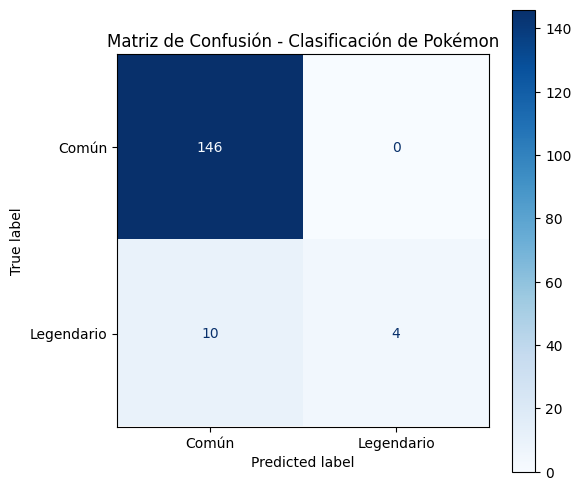

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Pasamos los tensores a arreglos de Numpy
y_real = y_val_tensor.cpu().numpy()
y_pred = predicciones_finales.cpu().numpy()

# 2. Generar el Reporte de Clasificación (F1-Score, Precision, Recall)
print("--- Reporte de Clasificación ---")
print(classification_report(y_real, y_pred, target_names=['Común', 'Legendario']))

# 3. Generar y dibujar la Matriz de Confusión
cm = confusion_matrix(y_real, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Común', 'Legendario'])

# Configurar el estilo del gráfico
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusión - Clasificación de Pokémon")
plt.show()

### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



#### Respuestas Preguntas
1. Gracias a los datos obtenidos y a la matriz de confusión, observamos que el modelo es excelente para identificar a los Pokémon comunes (146 aciertos y 0 errores). Sin embargo, le cuesta mucho más identificar a los legendarios, solo logró predecir 4 correctamente, mientras que se equivocó en 10 casos. Esto nos deja con una alta tasa de Falsos Negativos (FN), es decir, legendarios que la red consideró como criaturas comunes.

    Si tuvieramos que elegir un Pokémon para nuestro equipo basándonos en los errores del modelo, **teóricamente** la mejor opción sería un Falso Positivo (FP). Aunque nuestra red arrojó 0 casos de este tipo, un FP representaría un Pokémon de categoría común con estadísticas tan anormalmente altas que el modelo matemático lo confundiría con un legendario (lo que en el juego se conoce como un pseudo-legendario).
    
    Pero mirando nuestros **resultados reales**, elegiriamos uno de los 10 Falsos Negativos (FN). La ventaja sería llevar un Pokémon legendario genuino en el equipo, pero cuyas estadísticas base quizás no son las más fuertes, esto hará que el oponente nos subestime.    
---

2.

In [18]:
# Filtramos solo los legendarios del dataset original
legendarios = data[data['Legendary'] == True]

# Los ordenamos por su total de estadísticas (de menor a mayor) y sacamos los 5 primeros
legendarios_debiles = legendarios.sort_values(by='Total').head(10)


display(legendarios_debiles[['Name', 'Type 1', 'Total', 'HP', 'Attack', 'Defense', 'Speed']])

,Name,Type 1,Total,HP,Attack,Defense,Speed
156,Articuno,Ice,580,90,85,100,85
157,Zapdos,Electric,580,90,90,85,100
158,Moltres,Fire,580,90,100,90,90
263,Entei,Fire,580,115,115,85,100
262,Raikou,Electric,580,90,85,75,115
416,Registeel,Steel,580,80,75,150,50
414,Regirock,Rock,580,80,100,200,50
264,Suicune,Water,580,100,75,115,85
415,Regice,Ice,580,80,50,100,50
538,Mesprit,Psychic,580,80,105,105,80


Al analizar los casos de Falsos Negativos, identificamos que el modelo se equivoca con Pokémon como Articuno. 

**¿Por qué se equivoco el modelo?**

Este error ocurre porque MLP busca patrones numéricos para activar su predicción. La red aprendió que la etiqueta "Legendary" tiene valores extremadamente altos (sobre 600 puntos totales). Articuno posee un total de 580, lo cual es bajo para un legendario y se iguala con Pokémon comunes en su última evolución. Al no cumplir con el umbral númerico que la red espera, la función de activación Sigmoide lo clasifica erróneamente.

### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.

    Si, se utilizó el modelo Gemini 3.1 Pro como asistente
2. ¿En qué parte o partes de la tarea utilizó estas herramientas?

    Se utilizó a modo de consultas, siguiendo el modelo pair programming.
    - **Comprensión teórica:** Para repasar el funcionamiento de las funciones de activación y las funciones de pérdida aplicadas a arquitectura MLP.
    - **Debugging:** Para identificar y solucionar errores de compatibilidad de tipos de datos al pasar de estructuras de pandas a matrices de NumPy
